In [56]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('../names.txt', 'r').read().splitlines()
print(words[:8])
print(len(words))

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
32033


In [3]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s: i for i, s in enumerate(chars, start=1)}
stoi['.'] = 0 # use as start/end token
itos = {i: s for s, i in stoi.items()}
print(itos)
print(stoi)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [4]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []

for w in words[:5]:
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--->', ch)
        context = context[1:] + [ix] # shifting the contex window

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [5]:
X.shape, X.dtype, Y.shape, Y.dtype 

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [6]:
C = torch.randn((27, 2))

In [7]:
# indexing is equivalent to use of one-hot encoding done in the first layer of neural network
print(C[5])
print(F.one_hot(torch.tensor(5), num_classes=27).float() @ C)

tensor([0.4890, 1.4123])
tensor([0.4890, 1.4123])


In [8]:
print(X[13, 2])
print(C[X][13, 2])
print(C[1])

tensor(1)
tensor([0.9054, 1.5425])
tensor([0.9054, 1.5425])


In [9]:
emb = C[X]

W1 = torch.randn(6, 100)
b1 = torch.randn(100)

emb = torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], dim=1)

print(emb.shape, W1.shape)
emb @ W1 + b1


torch.Size([32, 6]) torch.Size([6, 100])


tensor([[-0.8525, -1.2826, -1.1531,  ..., -4.1096, -3.0861,  0.8395],
        [-3.9889, -2.1127,  1.3720,  ..., -4.1106, -3.0440, -0.0563],
        [-0.7883, -1.5218,  0.9484,  ..., -3.6496,  4.8537, -0.7940],
        ...,
        [-1.3741, -1.0396,  1.3945,  ...,  0.6670, -2.6359,  1.1740],
        [ 1.9312, -0.4227, -2.6520,  ..., -1.1373,  0.8071,  0.9959],
        [-5.7176, -1.8407, -0.0407,  ..., -0.2110, -6.4462,  0.4752]])

- view() function is highly efficient. cat() or unbind() create the output tensor in a new memory place, whereas view() uses the same memory.  
- PyTorch keep the actual data as a 1D array (call .storage() from a tensor) as it in the actual computer memory.
- It keeps an internal parameters (storage offset, strides and shapes) to manipulate the data as if N-dimentional array during tensor operations. 
- For details about PyTorch internals, see [this post](https://blog.ezyang.com/2019/05/pytorch-internals/).

In [10]:
a = torch.arange(80)
print(a.shape)
a = a.view(16, 5, 1)
print(a.shape)
a = a.view(1, 2, 5, 4, 2)
print(a.shape)
a = a.view(-1, 16)
print(a.shape)

torch.Size([80])
torch.Size([16, 5, 1])
torch.Size([1, 2, 5, 4, 2])
torch.Size([5, 16])


In [11]:
a = torch.arange(12)
a.storage()

/var/folders/xh/jv4dsp5n13nf07dl_7dskp140000gn/T/ipykernel_1409/1393808857.py:2: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  a.storage()


 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 12]

In [12]:
# always make sure that the broadcasting works as expected
print(b1.shape)
print((emb.view(-1, 6) @ W1).shape)
# Pytorch will act the bias with shape of (100) as shape of (32, 100)

torch.Size([100])
torch.Size([32, 100])


In [13]:
torch.tanh(emb.view(-1, 6) @ W1 + b1)

tensor([[-0.6924, -0.8572, -0.8188,  ..., -0.9995, -0.9958,  0.6855],
        [-0.9993, -0.9712,  0.8791,  ..., -0.9995, -0.9955, -0.0563],
        [-0.6575, -0.9090,  0.7391,  ..., -0.9986,  0.9999, -0.6607],
        ...,
        [-0.8796, -0.7777,  0.8842,  ...,  0.5830, -0.9898,  0.8256],
        [ 0.9588, -0.3992, -0.9901,  ..., -0.8135,  0.6680,  0.7599],
        [-1.0000, -0.9509, -0.0407,  ..., -0.2080, -1.0000,  0.4424]])

In [ ]:
# define vocabulary (each character mapped to a 2D vector)
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)

# define a 2-layer MLP
W1 = torch.randn(6, 100, generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn(100, 27, generator=g)
b2 = torch.randn(27, generator=g)

# forward pass
emb = C[X].view(-1, 6)
h = torch.tanh(emb @ W1 + b1) # first layer
logits = h @ W2 + b2 # second layer: no activation, producing raw outputs (logits)

# calculate the loss
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
loss = -probs[torch.arange(Y.shape[0]), Y].log().mean() # Negative Log-Likelihood (NLL) loss
print('loss:', loss)

loss: tensor(17.7697)


In [23]:
# we don't need to reinvent the wheel.
F.cross_entropy(logits, Y)

tensor(17.7697)

In [31]:
# define vocabulary (each character mapped to a 2D vector)
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)

# define a 2-layer MLP
W1 = torch.randn(6, 100, generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn(100, 27, generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

for k in range(1, 11):
    # forward pass
    emb = C[X].view(-1, 6)
    h = torch.tanh(emb @ W1 + b1) # first layer
    logits = h @ W2 + b2 # second layer: no activation, producing raw outputs (logits)

    # calculate the loss
    loss = F.cross_entropy(logits, Y)
    print(k, loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data -= 0.1 * p.grad

1 17.76971435546875
2 13.656402587890625
3 11.298770904541016
4 9.452457427978516
5 7.984263896942139
6 6.891320705413818
7 6.100014686584473
8 5.452036380767822
9 4.898151874542236
10 4.414664268493652


In [34]:
# now we can train the network on full dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []

for w in words:
    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '--->', ch)
        context = context[1:] + [ix] # shifting the contex window

X = torch.tensor(X)
Y = torch.tensor(Y)

In [37]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [48]:
# define vocabulary (each character mapped to a 2D vector)
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)

# define a 2-layer MLP
W1 = torch.randn(6, 100, generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn(100, 27, generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

nparams = sum(p.nelement() for p in parameters)
print('number of parameters:', nparams)

number of parameters: 3481


In [49]:
for p in parameters:
    p.requires_grad = True

for k in range(1000):
    # minibatch construct (for faster convergence)
    # instead of taking slow exact steps, take quick, noisy but good enough steps
    ix = torch.randint(0, X.shape[0], (32, ))
    
    # forward pass
    emb = C[X[ix]].view(-1, 6)
    h = torch.tanh(emb @ W1 + b1) # first layer
    logits = h @ W2 + b2 # second layer: no activation, producing raw outputs (logits)

    # calculate the loss
    loss = F.cross_entropy(logits, Y[ix])
    print(k, loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data -= 0.1 * p.grad

0 16.78647804260254
1 16.22416877746582
2 13.773971557617188
3 14.00375747680664
4 15.063871383666992
5 14.6050443649292
6 12.972978591918945
7 12.740849494934082
8 11.77699089050293
9 12.69403076171875
10 11.577655792236328
11 13.10047435760498
12 10.293745040893555
13 11.256890296936035
14 10.216803550720215
15 8.222373962402344
16 10.835959434509277
17 10.941580772399902
18 8.789833068847656
19 8.588258743286133
20 9.060755729675293
21 8.63561725616455
22 7.819587230682373
23 7.587696552276611
24 7.8629350662231445
25 6.9010491371154785
26 8.509645462036133
27 6.823181629180908
28 7.59282922744751
29 8.492286682128906
30 6.313126087188721
31 7.077383518218994
32 5.5336151123046875
33 7.808941841125488
34 6.994938373565674
35 5.934221267700195
36 6.3625922203063965
37 5.503702163696289
38 6.4704999923706055
39 4.29818058013916
40 5.047604560852051
41 5.41706657409668
42 5.428709506988525
43 5.804412364959717
44 6.398321151733398
45 7.05496883392334
46 6.636452674865723
47 7.010368347

In [66]:
# how to pick a good learning rate?
lre = torch.linspace(-3, 0, 1000) # exponents
lrs = 10**lre

# start from a small learning rate to larger
lri = []
lossi = []

for p in parameters:
    p.requires_grad = True

for i in range(1000):
    # minibatch construct (for faster convergence)
    # instead of taking slow exact steps, take quick, noisy but good enough steps
    ix = torch.randint(0, X.shape[0], (32, ))
    
    # forward pass
    emb = C[X[ix]].view(-1, 6)
    h = torch.tanh(emb @ W1 + b1) # first layer
    logits = h @ W2 + b2 # second layer: no activation, producing raw outputs (logits)

    # calculate the loss
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = lrs[i]
    for p in parameters:
        p.data -= lr * p.grad

    # track stats
    lri.append(lre[i])
    lossi.append(loss.item())


4.4916534423828125
3.96030855178833
4.346409797668457
4.045167922973633
4.893618106842041
4.187793254852295
5.41664981842041
3.8827528953552246
4.381821632385254
4.364006996154785
6.0562334060668945
5.182370662689209
5.041562080383301
4.36107063293457
4.596708297729492
4.209278106689453
6.5242133140563965
4.434128761291504
5.031467437744141
4.882740497589111
4.401767253875732
4.249682426452637
5.985044002532959
4.937852382659912
3.624343156814575
5.237112998962402
4.439413547515869
4.486588001251221
4.554790496826172
5.503259181976318
4.46407413482666
5.083440780639648
5.0266852378845215
3.89099383354187
5.219649314880371
4.443013668060303
5.564422130584717
5.391463756561279
4.10109806060791
5.8946990966796875
4.227536201477051
4.3068671226501465
3.7672483921051025
4.910516738891602
4.125658988952637
4.920083999633789
5.567080497741699
4.665772438049316
5.001418590545654
4.394107341766357
5.1401872634887695
4.706610679626465
4.373580455780029
3.835960626602173
4.918064594268799
4.72739

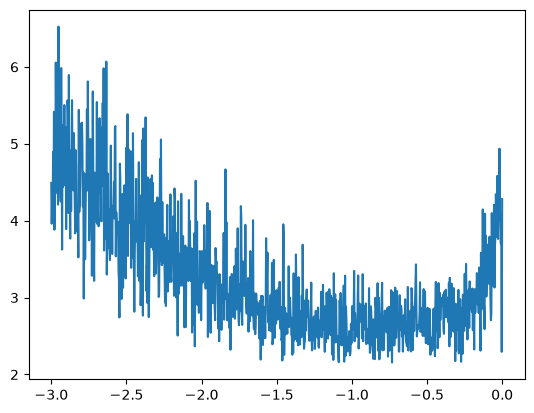

In [72]:
plt.plot(lri, lossi)

In [ ]:
# so somewhere around -1.0 is a very good learning rate (0.1)